# Fitting a Line to Data with emcee
Following the [emcee tutorial](https://emcee.readthedocs.io/en/stable/tutorials/line/) applied to `line-1.dat` and `line-2.dat`.
True line: **Y = -0.91 X + 4.0**

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import emcee
import corner

TRUE_M, TRUE_B, TRUE_F = -0.91, 4.0, None   # f unknown
LABELS = ["m", "b", "log(f)"]

## 1. Load data  (rows: x, y, σ_y)

In [20]:
def load(path):
    rows = np.loadtxt(path)
    return rows[0], rows[1], rows[2]   # x, y, yerr

x1, y1, e1 = load('data/line-1.dat')
x2, y2, e2 = load('data/line-2.dat')
print(f'line-1: {len(x1)} pts   line-2: {len(x2)} pts')

line-1: 50 pts   line-2: 50 pts


## 2. Model
Likelihood with underestimated errors (parameter `log_f`):
$$\ln p = -\frac{1}{2}\sum_n\left[\frac{(y_n - mx_n - b)^2}{s_n^2} + \ln(2\pi s_n^2)\right], \quad s_n^2 = \sigma_n^2 + (mx_n+b)^2 e^{2\ln f}$$
Uniform priors:  $m\in(-5,0.5)$,  $b\in(0,10)$,  $\ln f\in(-10,1)$.

In [21]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model  = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

## 3. Maximum Likelihood Estimate (starting point for walkers)

In [22]:
def run_mle(x, y, yerr, label):
    nll = lambda theta: -log_likelihood(theta, x, y, yerr)
    soln = opt.minimize(nll, [-0.9, 4.0, np.log(0.5)], method='Nelder-Mead')
    m, b, lf = soln.x
    print(f'{label}  MLE:  m={m:.4f}  b={b:.4f}  f={np.exp(lf):.4f}')
    return soln

soln1 = run_mle(x1, y1, e1, 'line-1')
soln2 = run_mle(x2, y2, e2, 'line-2')

line-1  MLE:  m=-0.9100  b=4.0000  f=0.0000
line-2  MLE:  m=-0.9503  b=4.2197  f=0.4162


## 4. Run emcee  (32 walkers, 5000 steps)

In [24]:
def run_emcee(soln, x, y, yerr, nwalkers=64, nsteps=5000):
    ndim = 3
    # Clampea log_f al interior del prior antes de perturbar
    start = soln.x.copy()
    start[2] = np.clip(start[2], -8.0, 0.5)
    scatter = np.array([0.01, 0.05, 0.3])

    rng = np.random.default_rng(42)
    pos = np.empty((nwalkers, ndim))
    n, max_tries = 0, 10_000
    for _ in range(max_tries):
        if n == nwalkers:
            break
        candidate = start + scatter * rng.standard_normal(ndim)
        if np.isfinite(log_probability(candidate, x, y, yerr)):
            pos[n] = candidate
            n += 1
    if n < nwalkers:
        raise RuntimeError(f"Only {n}/{nwalkers} valid starting positions found — widen prior or reduce scatter")

    moves = [(emcee.moves.DEMove(), 0.8),
             (emcee.moves.DESnookerMove(), 0.2)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability,
                                    args=(x, y, yerr), moves=moves)
    sampler.run_mcmc(pos, nsteps, progress=True)
    return sampler

print('--- line-1 ---')
sampler1 = run_emcee(soln1, x1, y1, e1)
print('--- line-2 ---')
sampler2 = run_emcee(soln2, x2, y2, e2)

--- line-1 ---


100%|██████████| 5000/5000 [00:03<00:00, 1267.95it/s]


--- line-2 ---


100%|██████████| 5000/5000 [00:04<00:00, 1195.45it/s]


## 5. Burn-in, thinning and autocorrelation time

In [25]:
def get_flat_samples(sampler, label):
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        tau = np.nan_to_num(tau, nan=100.0)
    except Exception:
        tau = np.full(3, 100.0)
    burnin = int(3 * np.max(tau))
    thin   = max(1, int(np.max(tau) / 2))
    flat   = sampler.get_chain(discard=burnin, thin=thin, flat=True)
    print(f"{label}  τ={tau.round(1)}  burn-in={burnin}  thin={thin}  samples={len(flat)}")
    return flat

flat1 = get_flat_samples(sampler1, "line-1")
flat2 = get_flat_samples(sampler2, "line-2")

line-1  τ=[12.7 12.8 12.4]  burn-in=38  thin=6  samples=52928
line-2  τ=[10.9 10.9 11.7]  burn-in=35  thin=5  samples=63552


## 6. Trace plots

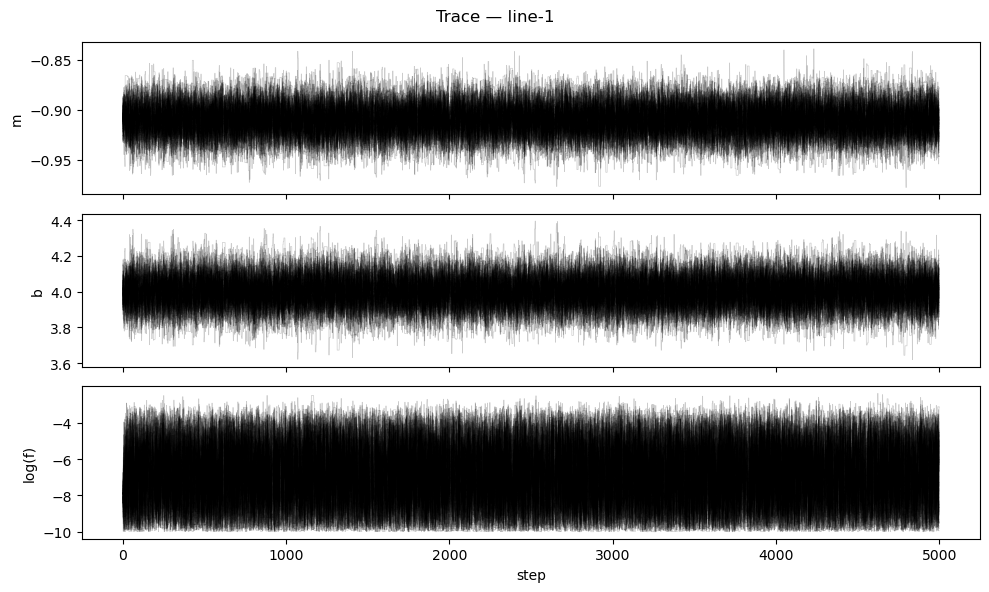

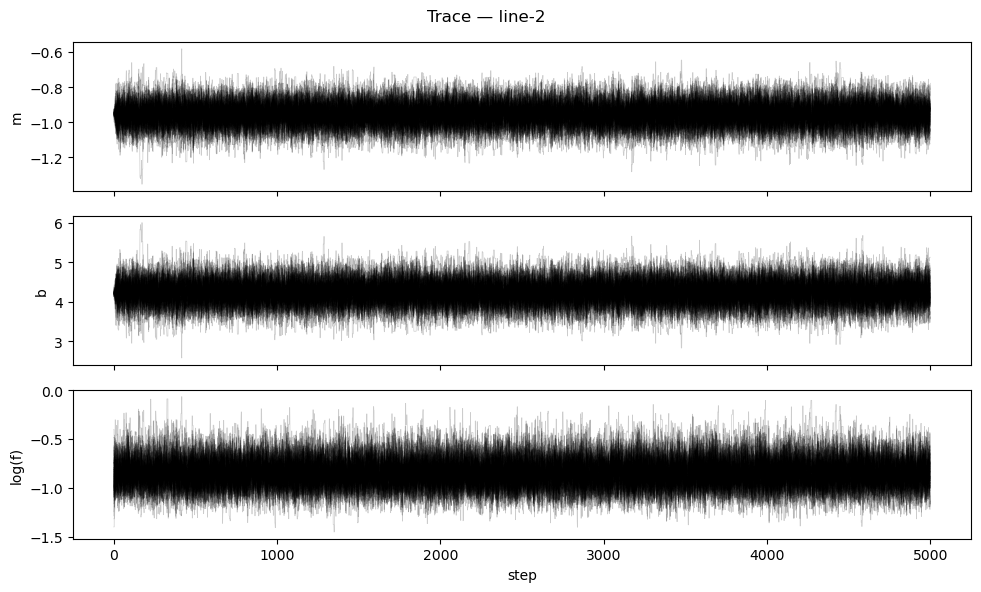

In [26]:
def plot_traces(sampler, title):
    samples = sampler.get_chain()
    fig, axes = plt.subplots(3, figsize=(10, 6), sharex=True)
    for i, (ax, lbl) in enumerate(zip(axes, LABELS)):
        ax.plot(samples[:, :, i], 'k', alpha=0.2, lw=0.5)
        ax.set_ylabel(lbl)
    axes[-1].set_xlabel('step')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_traces(sampler1, 'Trace — line-1')
plot_traces(sampler2, 'Trace — line-2')

## 7. Corner plots  (marginalized posteriors)

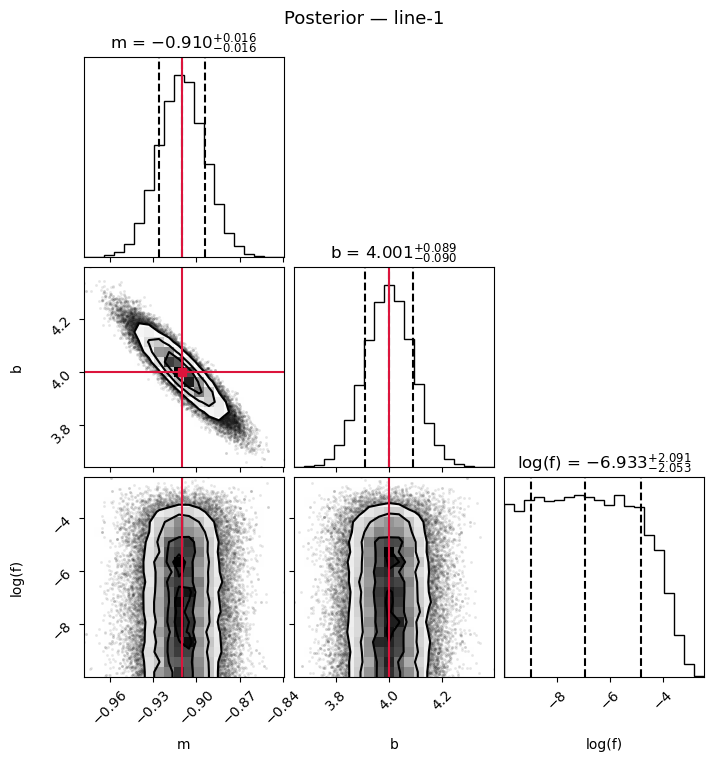

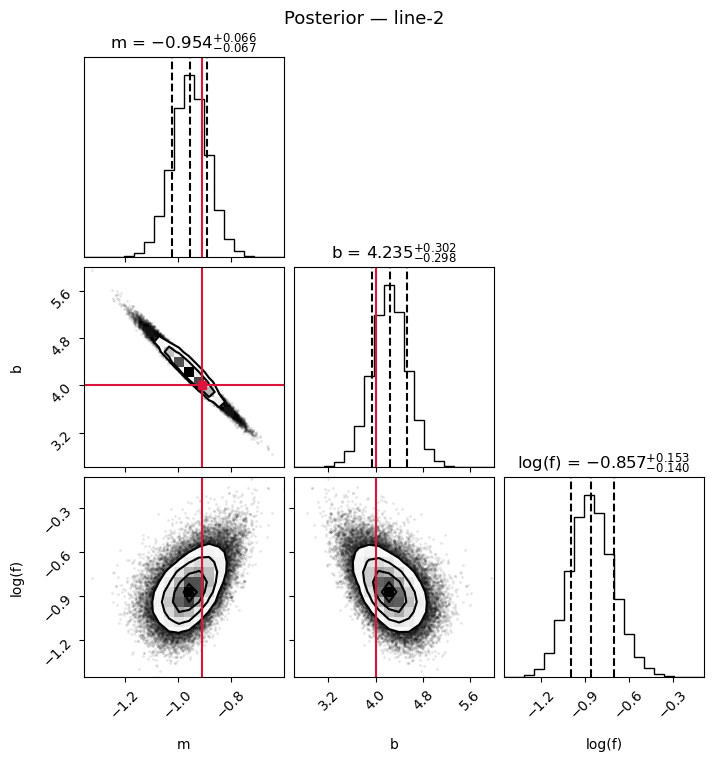

In [27]:
def plot_corner(flat, title):
    fig = corner.corner(flat, labels=LABELS,
                        truths=[TRUE_M, TRUE_B, None],
                        quantiles=[0.16, 0.5, 0.84],
                        show_titles=True, title_fmt='.3f',
                        truth_color='crimson')
    fig.suptitle(title, y=1.01, fontsize=13)
    plt.show()

plot_corner(flat1, 'Posterior — line-1')
plot_corner(flat2, 'Posterior — line-2')

## 8. Data + posterior predictive lines

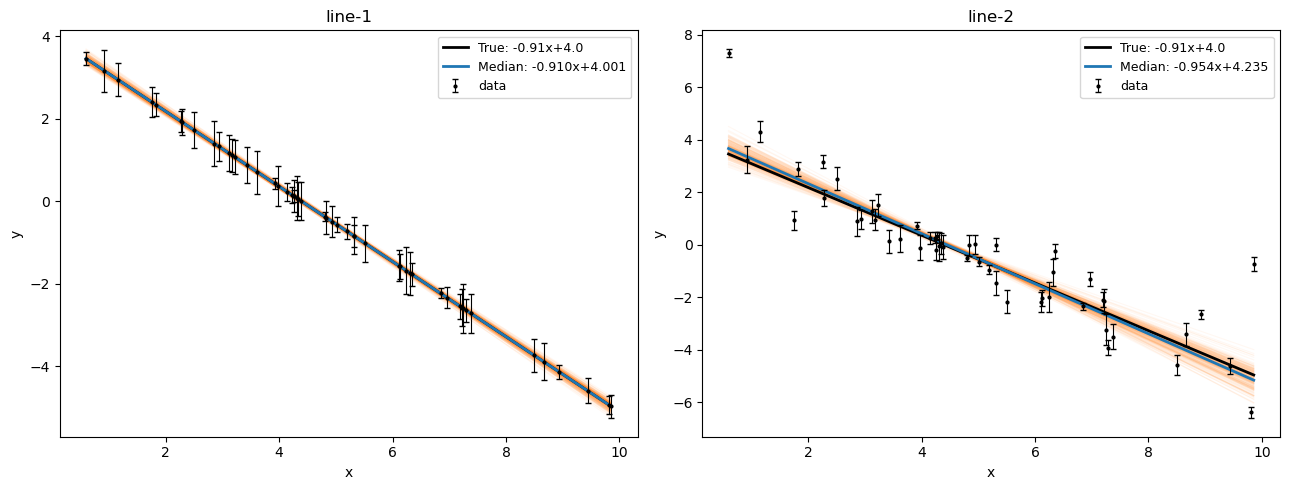

In [28]:
def plot_fit(ax, x, y, yerr, flat, title):
    x0 = np.linspace(x.min(), x.max(), 300)
    inds = np.random.randint(len(flat), size=200)
    for s in flat[inds]:
        ax.plot(x0, s[0]*x0 + s[1], color='C1', alpha=0.05, lw=0.8)
    ax.errorbar(x, y, yerr=yerr, fmt='.k', capsize=2, ms=4, elinewidth=0.8,
                label='data', zorder=5)
    ax.plot(x0, TRUE_M*x0 + TRUE_B, 'k', lw=2, label=f'True: {TRUE_M}x+{TRUE_B}')
    med = np.median(flat, axis=0)
    ax.plot(x0, med[0]*x0 + med[1], 'C0', lw=2,
            label=f'Median: {med[0]:.3f}x+{med[1]:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title); ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_fit(axes[0], x1, y1, e1, flat1, 'line-1')
plot_fit(axes[1], x2, y2, e2, flat2, 'line-2')
plt.tight_layout(); plt.show()

## 9. Parameter estimates  (16th, 50th, 84th percentiles)

In [29]:
def print_results(flat, label):
    print(f'\n{label}')
    print(f'  {"param":>8}  {"16%":>10}  {"50% (median)":>14}  {"84%":>10}  {"-σ":>8}  {"+σ":>8}')
    print('  ' + '-'*64)
    for i, lbl in enumerate(LABELS):
        p16, p50, p84 = np.percentile(flat[:, i], [16, 50, 84])
        print(f'  {lbl:>8}  {p16:>10.4f}  {p50:>14.4f}  {p84:>10.4f}  {p50-p16:>8.4f}  {p84-p50:>8.4f}')
    print(f'\n  True:  m={TRUE_M}  b={TRUE_B}  f=unknown')

print_results(flat1, 'line-1.dat')
print_results(flat2, 'line-2.dat')


line-1.dat
     param         16%    50% (median)         84%        -σ        +σ
  ----------------------------------------------------------------
         m     -0.9260         -0.9101     -0.8939    0.0159    0.0162
         b      3.9105          4.0005      4.0895    0.0901    0.0890
    log(f)     -8.9864         -6.9331     -4.8424    2.0533    2.0907

  True:  m=-0.91  b=4.0  f=unknown

line-2.dat
     param         16%    50% (median)         84%        -σ        +σ
  ----------------------------------------------------------------
         m     -1.0206         -0.9539     -0.8882    0.0667    0.0656
         b      3.9370          4.2353      4.5369    0.2983    0.3016
    log(f)     -0.9970         -0.8566     -0.7035    0.1404    0.1531

  True:  m=-0.91  b=4.0  f=unknown


## 10. Convergence Tests 

In [30]:
## Convergence diagnostics
from itertools import product

flat_all  = [flat1, flat2]
samp_all  = [sampler1, sampler2]
names     = ['line-1', 'line-2']

for name, flat, sampler in zip(names, flat_all, samp_all):
    chain = sampler.get_chain()           # (nsteps, nwalkers, ndim)
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')

    # 1. Acceptance fraction (target 0.2–0.5)
    af = sampler.acceptance_fraction
    print(f'  Acceptance fraction:  mean={af.mean():.3f}  min={af.min():.3f}  max={af.max():.3f}')

    # 2. Autocorrelation time
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        tau = np.nan_to_num(tau, nan=np.nan)
        print(f'  Autocorr time τ:      {np.round(tau, 1)}')
        print(f'  Steps/τ (>50 ok):     {np.round(chain.shape[0]/tau, 1)}')
    except Exception as e:
        print(f'  Autocorr time:        could not compute ({e})')

    # 3. Gelman-Rubin R-hat (per parameter, <1.01 = converged)
    # Each walker is treated as an independent chain
    M  = chain.shape[1]   # nwalkers
    N  = chain.shape[0]   # nsteps (post-burnin not applied here intentionally)
    W  = chain.var(axis=0, ddof=1).mean(axis=0)           # within-chain variance
    B  = N * chain.mean(axis=0).var(axis=0, ddof=1)       # between-chain variance
    Rhat = np.sqrt(((N-1)/N + B/(N*W)))
    print(f'  Gelman-Rubin R-hat:   {np.round(Rhat, 4)}  (<1.01 = converged)')

    # 4. Effective sample size
    try:
        ess = flat.shape[0] / tau
        print(f'  Effective samples:    {np.round(ess).astype(int)}')
    except Exception:
        print(f'  Effective samples:    N/A')


  line-1
  Acceptance fraction:  mean=0.274  min=0.258  max=0.289
  Autocorr time τ:      [12.7 12.8 12.4]
  Steps/τ (>50 ok):     [392.6 390.7 404.3]
  Gelman-Rubin R-hat:   [1.0016 1.0015 1.001 ]  (<1.01 = converged)
  Effective samples:    [4156 4136 4280]

  line-2
  Acceptance fraction:  mean=0.386  min=0.371  max=0.400
  Autocorr time τ:      [10.9 10.9 11.7]
  Steps/τ (>50 ok):     [457.4 457.9 427.1]
  Gelman-Rubin R-hat:   [1.0007 1.0007 1.0006]  (<1.01 = converged)
  Effective samples:    [5813 5820 5428]
